# Email Spam Classifier
This notebook implements and compares several machine learning algorithms to classify emails as spam or ham using the Spambase dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Dataset
We use the `ucimlrepo` package to fetch the Spambase dataset (ID: 94).

In [5]:
# Fetch dataset
spambase = fetch_ucirepo(id=94)

# Data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")

# Check for missing values
print("\nMissing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum().sum())

Features shape: (4601, 57)
Targets shape: (4601, 1)

Missing values in X: 0
Missing values in y: 0


## 2. Preprocessing
Split the data into training and testing sets, and then scale the features since SVM and k-NN are sensitive to the scale of input features.

In [6]:
# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Flatten y if needed
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")

Data split and scaled successfully.


## 3. Model Training and Evaluation
We will train four algorithms:
1. Logistic Regression
2. Support Vector Machine
3. k-Nearest Neighbors
4. Naive Bayes

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "k-NN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "accuracy": acc,
        "cm": confusion_matrix(y_test, y_pred),
        "y_proba": y_proba
    }
    
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9294
SVM Accuracy: 0.9273
k-NN Accuracy: 0.9077
Naive Bayes Accuracy: 0.8328


## 4. Comparison of Algorithms
Let's visualize the accuracy scores of the different models.

C:\Users\janas\AppData\Local\Temp\ipykernel_12328\2568602674.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=acc_df, palette="viridis")


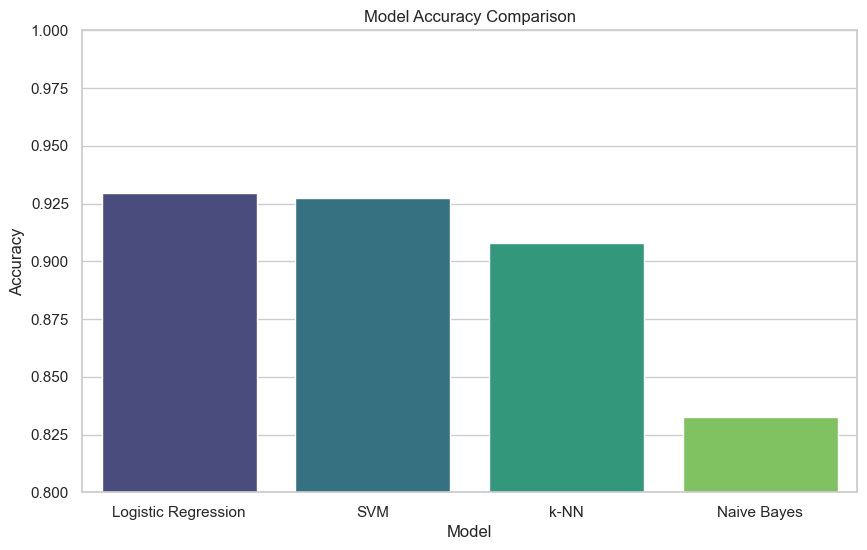

In [8]:
acc_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [r["accuracy"] for r in results.values()]
})

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=acc_df, palette="viridis")
plt.ylim(0.8, 1.0)
plt.title("Model Accuracy Comparison")
plt.show()

## 5. Confusion Matrices
Visualizing the confusion matrix for each algorithm.

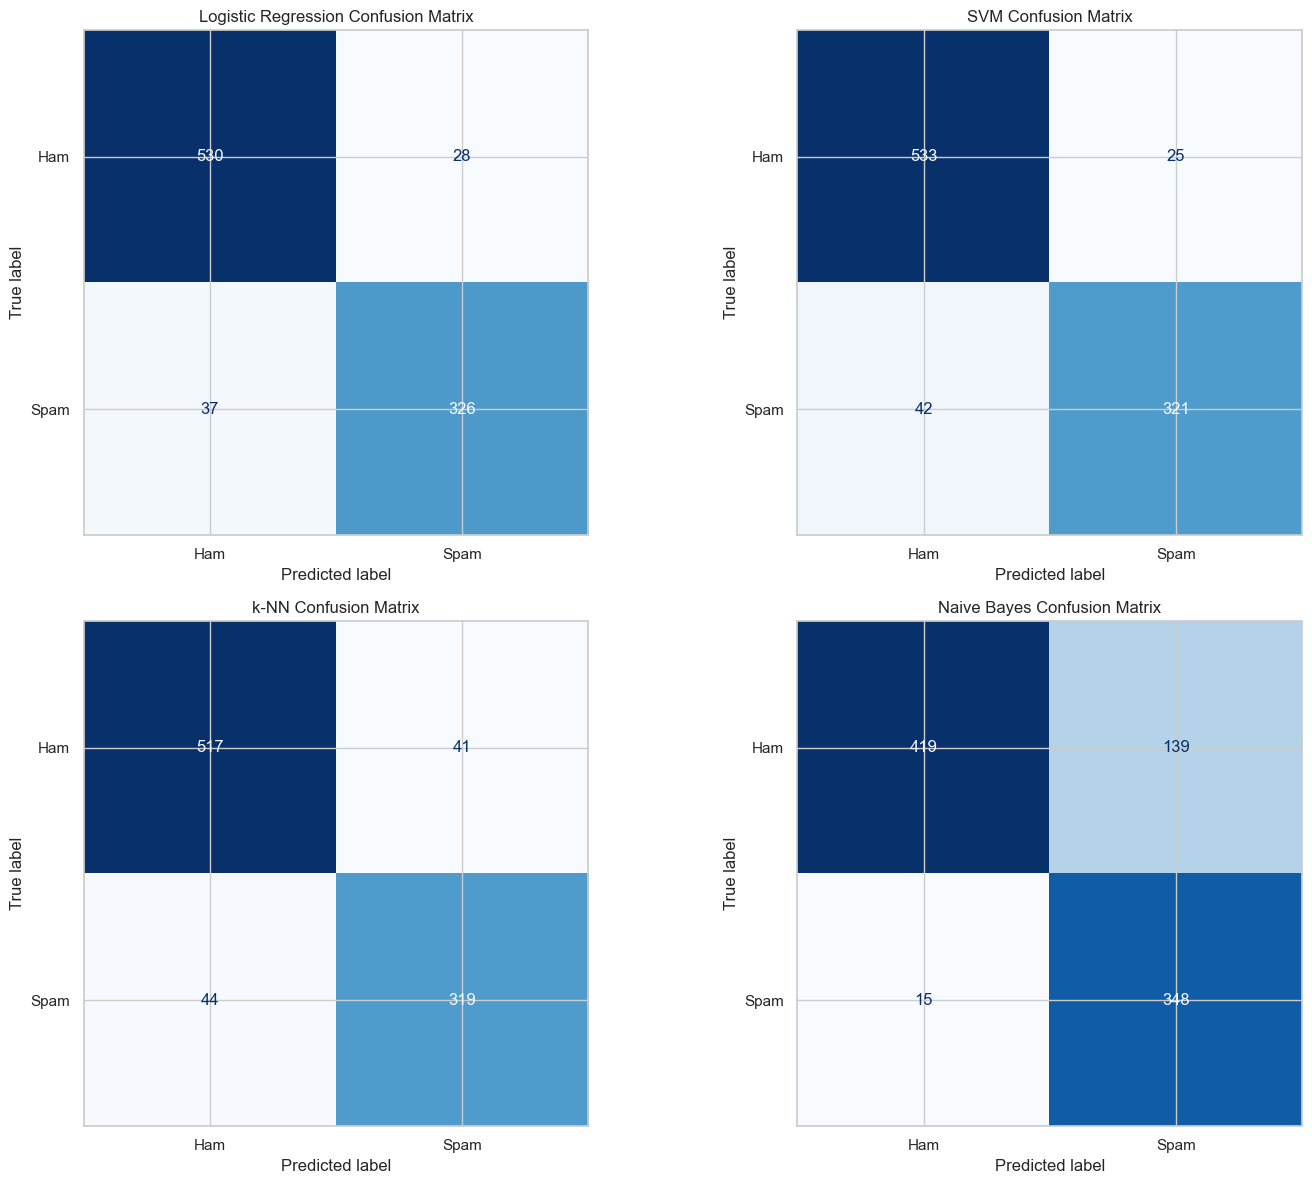

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, (name, data) in enumerate(results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=data["cm"], display_labels=['Ham', 'Spam'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

## 6. ROC Curves
Visualizing the Receiver Operating Characteristic (ROC) curves to compare the trade-off between sensitivity and specificity.

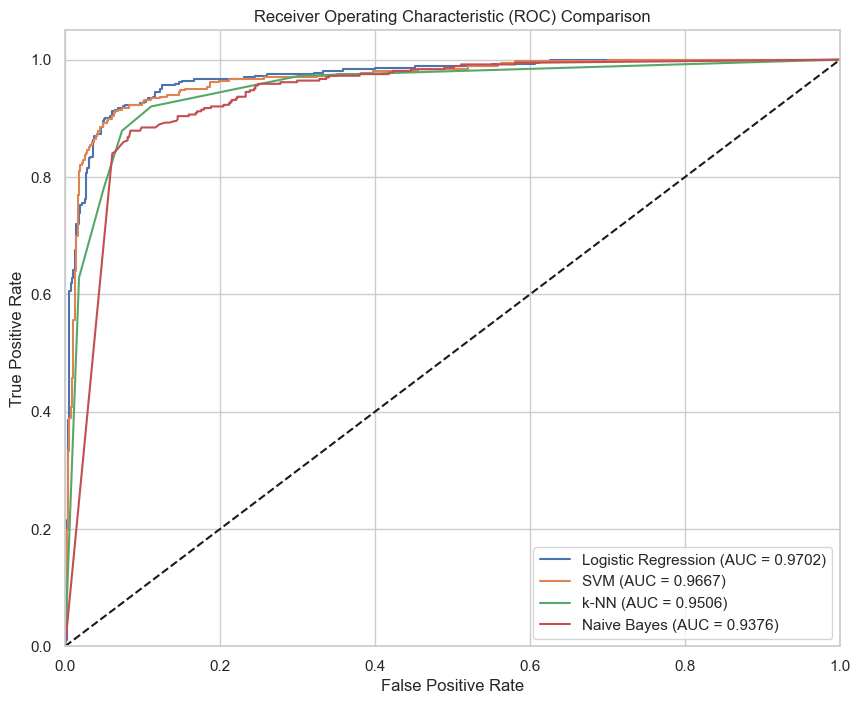

In [10]:
plt.figure(figsize=(10, 8))

for name, data in results.items():
    fpr, tpr, _ = roc_curve(y_test, data["y_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.show()